# Progress report 1: Microstrip
**Date:** 10-03-2026
**AUTHOR:** Mateo IBARRA GOMEZ

This report summarizes the work done on the HFSS simulations according to Romain's indications in *Simus pour Mateo - 2026-06-03.pptx*.

## Objective
-Through HFSS simulations of a microstrip and a GSG structure determine for which parameters the field fills a larger volume of the substrate. The parameters are the width of the line and the thickness of the substrate.

## Microstrip
Three values for w_line are considered: 30, 50, 200 um.
Four values for h_subs are considered: 50, 100, 200, 500 um.
Input power P_in = 1 mW

For each configuration w_line, h_subs, extract the surface for which Hx > 1 Oe

### Steps
1. The microstrip is visualized in the xz plane for each case to have a better idea of the dimensions
2. The guided wavelength lambda_g and the higher modes cut-off frequency f_c are calculated to choose L and the operation frequency
3. The parameters S11 and S21 are plotted for each case
4. The field Hx is plotted in the yz plane and x=0 to identify where Hx > 1 Oe
5. At the given y coordinate the field Hx is visualized in the xz plane to study the distribution of Hx in the substrate

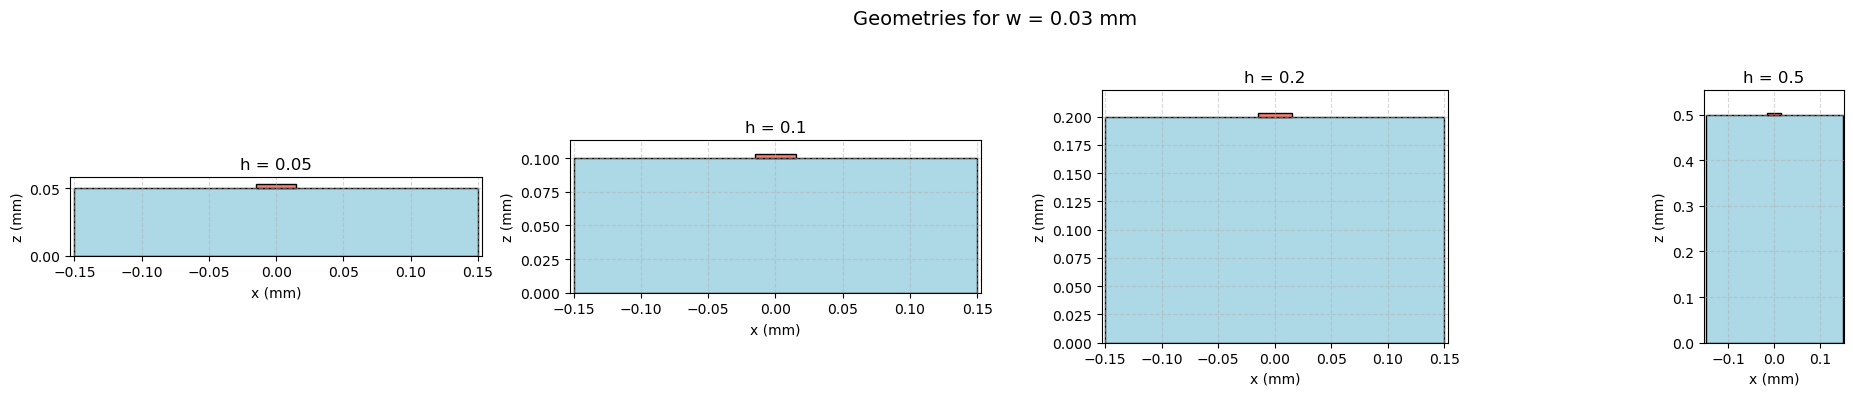

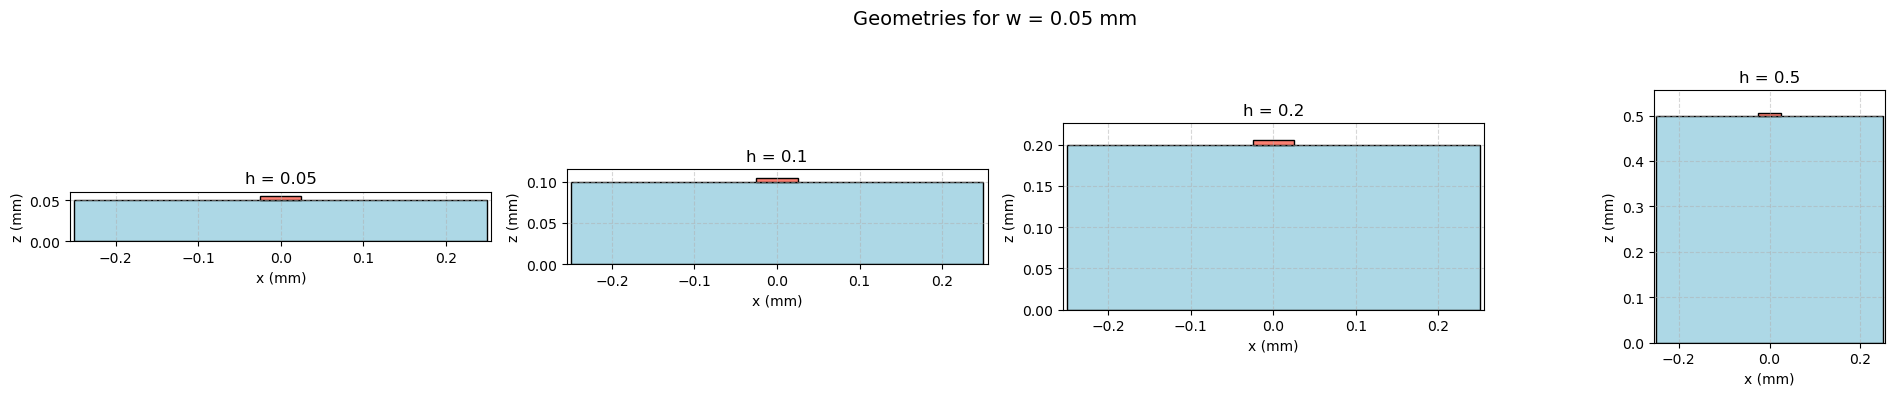

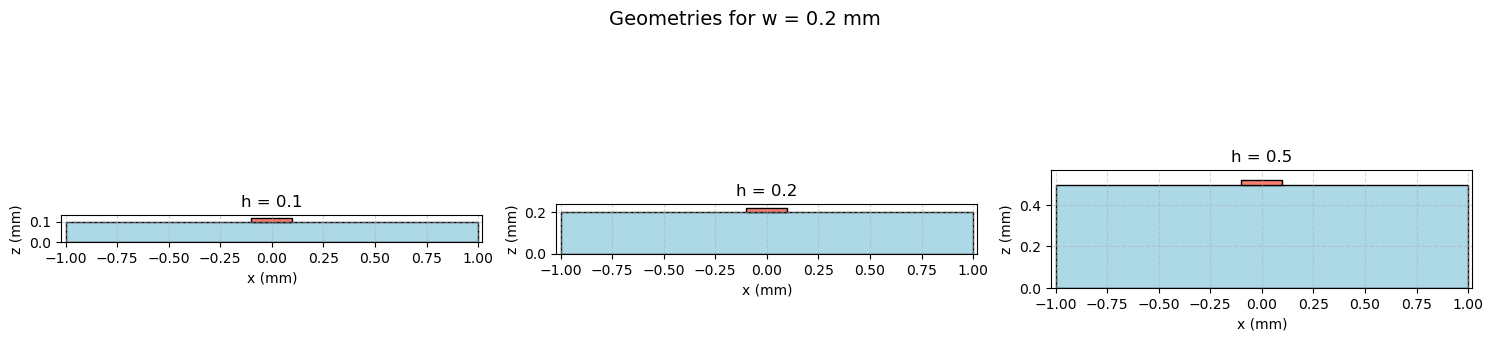

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


class GeometryCase:
    """Represents one (w, h) geometry configuration."""

    def __init__(self, w: float, h: float):
        self.w = w
        self.h = h

    @property
    def top_width(self) -> float:
        return self.w

    @property
    def top_height(self) -> float:
        return self.w / 10

    @property
    def bottom_width(self) -> float:
        return self.w * 10

    @property
    def bottom_height(self) -> float:
        return self.h

    def draw(self, ax):
        """Draw the stacked rectangles on the given axis."""
        # Bottom rectangle: centered at x = 0, base at y = 0
        bottom_x = -self.bottom_width / 2
        bottom_y = 0

        # Top rectangle: centered at x = 0, exactly on top of bottom rectangle
        top_x = -self.top_width / 2
        top_y = self.bottom_height

        bottom_rect = Rectangle(
            (bottom_x, bottom_y),
            self.bottom_width,
            self.bottom_height,
            facecolor="lightblue",
            edgecolor="black",
            label="Bottom rectangle"
        )

        top_rect = Rectangle(
            (top_x, top_y),
            self.top_width,
            self.top_height,
            facecolor="salmon",
            edgecolor="black",
            label="Top rectangle"
        )

        ax.add_patch(bottom_rect)
        ax.add_patch(top_rect)

        total_height = self.bottom_height + self.top_height
        max_width = max(self.bottom_width, self.top_width)

        ax.set_xlim(-max_width / 2 - 0.1 * self.w, max_width / 2 + 0.1 * self.w)
        ax.set_ylim(0, total_height + 0.1 * total_height)

        ax.set_aspect("equal")
        ax.set_title(f"h = {self.h}")
        ax.set_xlabel("x (mm)")
        ax.set_ylabel("z (mm)")
        ax.grid(True, linestyle="--", alpha=0.5)


class GeometryPlotter:
    """Loads data and creates grouped figures by unique w."""

    def __init__(self, csv_path: str):
        self.csv_path = csv_path
        self.df = None

    def load_data(self):
        """Read the CSV and keep only unique (w, h) pairs."""
        df = pd.read_csv(self.csv_path)

        # Keep only required columns
        df = df[["w [mm]", "h [mm]"]].dropna()

        # Remove duplicate (w, h) pairs
        df = df.drop_duplicates().sort_values(["w [mm]", "h [mm]"]).reset_index(drop=True)

        self.df = df

    def plot_grouped_by_w(self):
        """Create one figure per unique w value."""
        if self.df is None:
            raise ValueError("Data not loaded. Call load_data() first.")

        unique_w_values = sorted(self.df["w [mm]"].unique())

        for w_value in unique_w_values:
            group = self.df[self.df["w [mm]"] == w_value].sort_values("h [mm]")
            n = len(group)

            ncols = min(4, n)
            nrows = math.ceil(n / ncols)

            fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))

            # Make axes always iterable
            if n == 1:
                axes = [axes]
            else:
                axes = axes.flatten()

            fig.suptitle(f"Geometries for w = {w_value} mm", fontsize=14)

            for ax, (_, row) in zip(axes, group.iterrows()):
                case = GeometryCase(w=row["w [mm]"], h=row["h [mm]"])
                case.draw(ax)

            # Hide unused axes
            for ax in axes[len(group):]:
                ax.axis("off")

            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()


if __name__ == "__main__":
    plotter = GeometryPlotter("Project2_S_Parameter_Plots.csv")
    plotter.load_data()
    plotter.plot_grouped_by_w()

The following table shows for each couple w_line, h_subs, the corresponding effective permitivity, the cutoff frequency f_c of the first higher-order surface wave mode and the guided wavelength, in order to better choose the length L of the line and the frequency f_ext of the applied field in the simulations.

In [2]:
import numpy as np
import pandas as pd

def effective_permittivity(eps_r, h_subs, w_line):
    return (eps_r + 1) / 2 + (eps_r - 1) / 2 * (1 / np.sqrt(1 + 12 * h_subs / w_line))

# Constants
c = 3e8
eps_r = 12
f = 9.4e9  # Hz

h_subs = np.array((0.050, 0.100, 0.250)) * 1e-3
w_line = np.array((0.030, 0.050, 0.200)) * 1e-3

rows = []

for h in h_subs:
    # f_c depends only on h_subs
    f_c = c / (4 * h * np.sqrt(eps_r - 1))
    
    for w in w_line:
        eps_eff = effective_permittivity(eps_r, h, w)
        lambda_g = c / f / np.sqrt(eps_eff)
        
        rows.append({
            "h_subs (mm)": h * 1e3,
            "w_line (mm)": w * 1e3,
            "eps_eff": eps_eff,
            "f_c (GHz)": f_c * 1e-9,
            "lambda_g (mm)": lambda_g * 1e3,
        })

df = pd.DataFrame(rows)

# Optional: prettier formatting for terminal display
df = df.round({
    "h_subs (mm)": 3,
    "w_line (mm)": 3,
    "eps_eff": 3,
    "f_c (GHz)": 3,
    "lambda_g (mm)": 3
})

print(df.to_string(index=False))

 h_subs (mm)  w_line (mm)  eps_eff  f_c (GHz)  lambda_g (mm)
        0.05         0.03    7.700    452.267         11.501
        0.05         0.05    8.025    452.267         11.266
        0.05         0.20    9.250    452.267         10.494
        0.10         0.03    7.359    226.134         11.765
        0.10         0.05    7.600    226.134         11.577
        0.10         0.20    8.579    226.134         10.896
        0.25         0.03    7.047     90.453         12.022
        0.25         0.05    7.204     90.453         11.891
        0.25         0.20    7.875     90.453         11.373


Therefore, L << 10 mm, and f_ext << 90 GHz

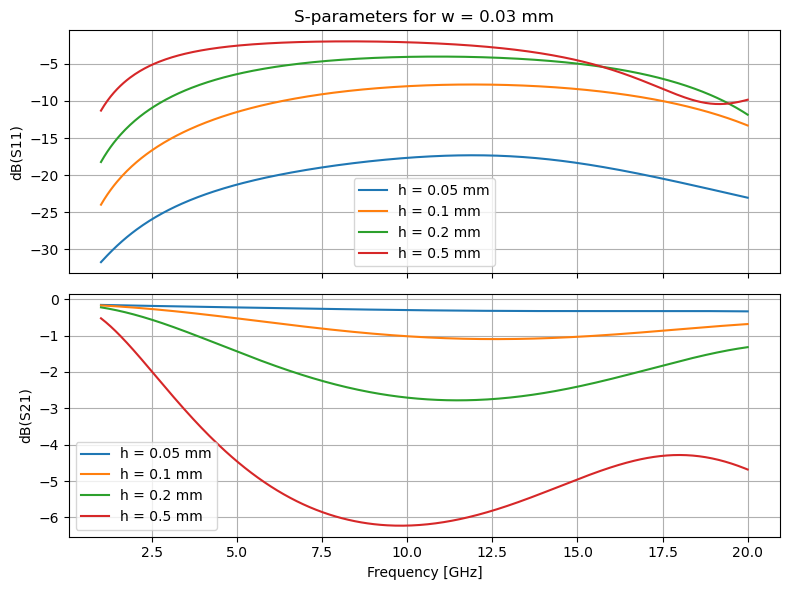

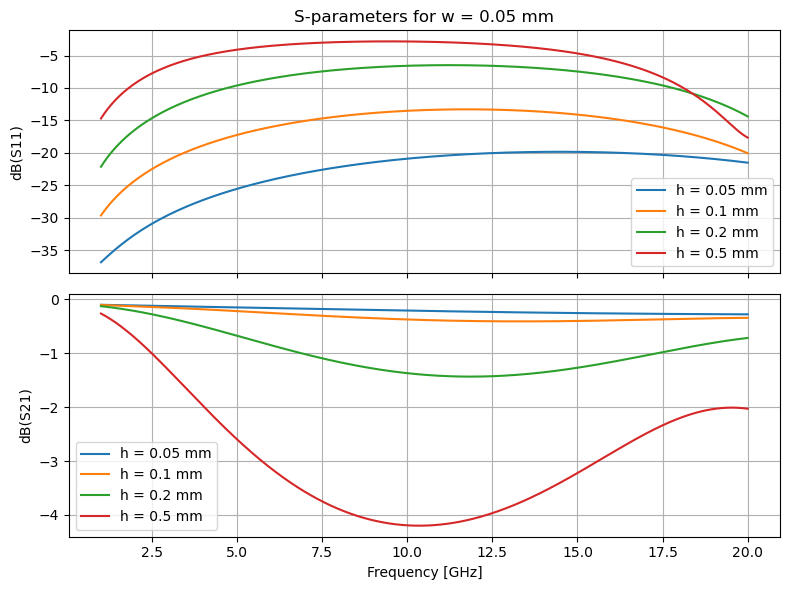

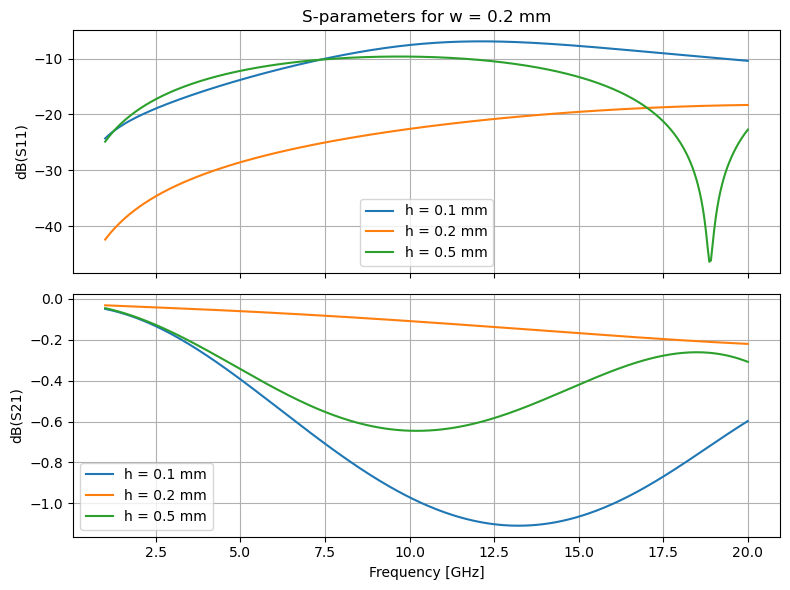

In [3]:
import matplotlib.pyplot as plt


class HFSSPlotter:
    def __init__(self, csv_file):
        self.csv_file = csv_file
        self.data = None

        self.col_h = "h [mm]"
        self.col_w = "w [mm]"
        self.col_freq = "Freq [GHz]"
        self.col_s11 = "dB(S(1,1)) []"
        self.col_s21 = "dB(S(2,1)) []"

    def load_data(self):
        self.data = pd.read_csv(self.csv_file)

    def check_columns(self):
        required_columns = [
            self.col_h,
            self.col_w,
            self.col_freq,
            self.col_s11,
            self.col_s21,
        ]

        missing = [col for col in required_columns if col not in self.data.columns]
        if missing:
            raise ValueError(f"Missing columns: {missing}")

    def plot_for_each_w(self):
        unique_w_values = sorted(self.data[self.col_w].unique())

        for w_value in unique_w_values:
            df_w = self.data[self.data[self.col_w] == w_value].copy()

            fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

            for h_value in sorted(df_w[self.col_h].unique()):
                df_wh = df_w[df_w[self.col_h] == h_value].copy()
                df_wh = df_wh.sort_values(by=self.col_freq)

                axes[0].plot(
                    df_wh[self.col_freq],
                    df_wh[self.col_s11],
                    label=f"h = {h_value} mm"
                )

                axes[1].plot(
                    df_wh[self.col_freq],
                    df_wh[self.col_s21],
                    label=f"h = {h_value} mm"
                )

            axes[0].set_ylabel("dB(S11)")
            axes[0].set_title(f"S-parameters for w = {w_value} mm")
            axes[0].grid(True)
            axes[0].legend()

            axes[1].set_xlabel("Frequency [GHz]")
            axes[1].set_ylabel("dB(S21)")
            axes[1].grid(True)
            axes[1].legend()

            plt.tight_layout()
            plt.show()

    def run(self):
        self.load_data()
        self.check_columns()
        self.plot_for_each_w()


if __name__ == "__main__":
    csv_file = "Project2_S_Parameter_Plots.csv"
    plotter = HFSSPlotter(csv_file)
    plotter.run()

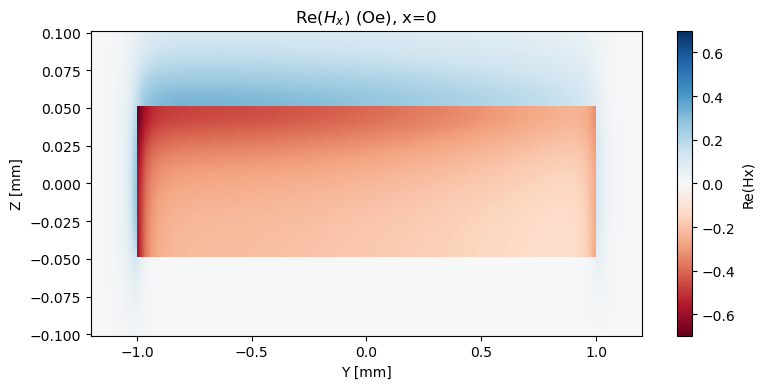

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

class HxMapPlotter:
    def __init__(self, filename):
        self.filename = filename

    def load_data(self):
        """
        Load numeric data from the file.
        Assumes:
          - line 1: metadata
          - line 2: column names
          - line 3 onward: numeric data
        """
        return np.loadtxt(self.filename, skiprows=2)

    def build_grid(self, data):
        y = data[:, 1]
        z = data[:, 2]
        hx_real = data[:, 3]

        y_unique = np.unique(y)
        z_unique = np.unique(z)

        grid = np.full((len(z_unique), len(y_unique)), np.nan)

        y_index = {val: i for i, val in enumerate(y_unique)}
        z_index = {val: i for i, val in enumerate(z_unique)}

        for yi, zi, hi in zip(y, z, hx_real):
            grid[z_index[zi], y_index[yi]] = hi*4*np.pi/1000*np.sqrt(1e-3)

        return y_unique, z_unique, grid

    def plot(self):
        """
        Plot the real part of Hx as a 2D color map.
        """
        data = self.load_data()
        y_unique, z_unique, grid = self.build_grid(data)
        vmax = np.nanmax(np.abs(grid))
        norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        
        plt.figure(figsize=(8, 4))
        plt.pcolormesh(y_unique*1e3, z_unique*1e3, grid, shading="auto",cmap="RdBu",norm=norm)
        plt.colorbar(label="Re(Hx)")
        plt.xlabel("Y [mm]")
        plt.ylabel("Z [mm]")
        plt.title('Re($H_x$) (Oe), x=0')
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    plotter = HxMapPlotter("h_x_data3.txt")
    plotter.plot()

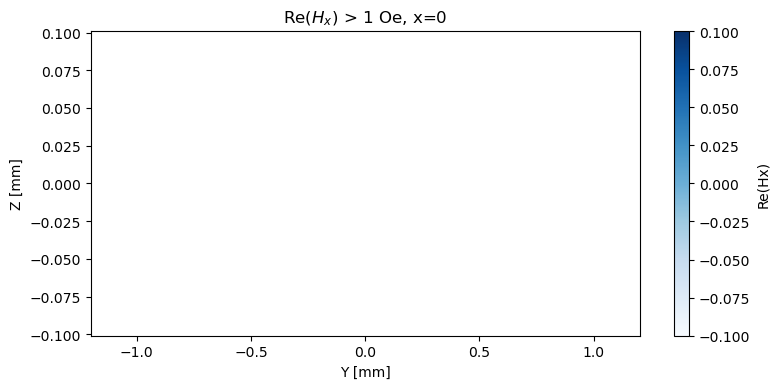

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

class HxMapPlotter:
    def __init__(self, filename):
        self.filename = filename

    def load_data(self):
        """
        Load numeric data from the file.
        Assumes:
          - line 1: metadata
          - line 2: column names
          - line 3 onward: numeric data
        """
        return np.loadtxt(self.filename, skiprows=2)

    def build_grid(self, data):
        y = data[:, 1]
        z = data[:, 2]
        hx_real = data[:, 3]

        y_unique = np.unique(y)
        z_unique = np.unique(z)

        grid = np.full((len(z_unique), len(y_unique)), np.nan)

        y_index = {val: i for i, val in enumerate(y_unique)}
        z_index = {val: i for i, val in enumerate(z_unique)}

        for yi, zi, hi in zip(y, z, hx_real):
            grid[z_index[zi], y_index[yi]] = np.abs(hi)*4*np.pi/1000*np.sqrt(1e-3)

        return y_unique, z_unique, grid

    def plot(self):
        """
        Plot the real part of Hx as a 2D color map.
        """
        data = self.load_data()
        y_unique, z_unique, grid = self.build_grid(data)
        #vmax = np.nanmax(np.abs(grid))
        #norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        
        plt.figure(figsize=(8, 4))
        grid[grid<1]=np.nan
        plt.pcolormesh(y_unique*1e3, z_unique*1e3, grid, shading="auto",cmap="Blues")
        plt.colorbar(label="Re(Hx)")
        plt.xlabel("Y [mm]")
        plt.ylabel("Z [mm]")
        plt.title('Re($H_x$) > 1 Oe, x=0')
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    plotter = HxMapPlotter("h_x_data3.txt")
    plotter.plot()